In [1]:
# jakob2019_figuras.ipynb
# Bloque 1 — Setup
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import ssl, certifi, os
from pathlib import Path

# SSL fix para cartopy
ssl._create_default_https_context = ssl.create_default_context
os.environ['SSL_CERT_FILE'] = certifi.where()

# Rutas
ROOT    = Path.cwd()
OUT_DIR = ROOT / 'datos' / 'procesados'
FIG_DIR = ROOT / 'figuras'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Cargar los 4 campos procesados
Q_R   = xr.open_dataarray(OUT_DIR / 'Q_R_2001_2009.nc')
P_E   = xr.open_dataarray(OUT_DIR / 'P_E_2001_2009.nc')
H     = xr.open_dataarray(OUT_DIR / 'H_2001_2009.nc')
D_RCE = xr.open_dataarray(OUT_DIR / 'D_RCE_2001_2009.nc')

print("Datos cargados:")
for name, da in [("Q_R", Q_R), ("P_E", P_E), ("H", H), ("D_RCE", D_RCE)]:
    print(f"  {name}: {da.shape}  {da.time.values[0]} → {da.time.values[-1]}")

Datos cargados:
  Q_R: (3287, 180, 360)  2001-01-01T00:00:00.000000000 → 2009-12-31T00:00:00.000000000
  P_E: (3287, 180, 360)  2001-01-01T00:00:00.000000000 → 2009-12-31T00:00:00.000000000
  H: (3287, 180, 360)  2001-01-01T00:00:00.000000000 → 2009-12-31T00:00:00.000000000
  D_RCE: (3287, 180, 360)  2001-01-01T00:00:00.000000000 → 2009-12-31T00:00:00.000000000


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


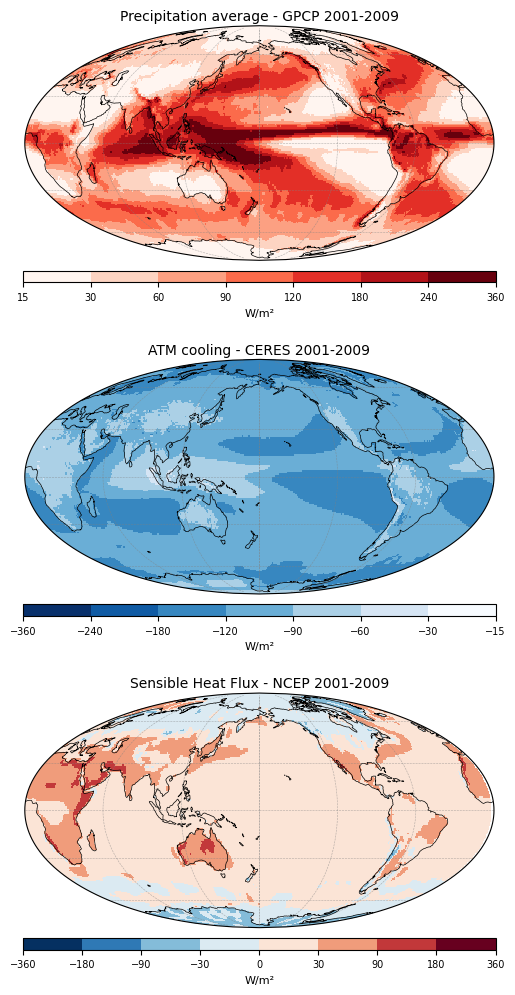

Guardada: fig01_jakob2019.png


In [2]:
# SSL fix para cartopy
ssl._create_default_https_context = ssl.create_default_context
os.environ['SSL_CERT_FILE'] = certifi.where()

# Rutas
OUT_DIR = ROOT / 'datos' / 'procesados'
FIG_DIR = ROOT / 'figuras'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Cargar datos procesados
Q_R = xr.open_dataarray(OUT_DIR / 'Q_R_2001_2009.nc')
P_E = xr.open_dataarray(OUT_DIR / 'P_E_2001_2009.nc')
H   = xr.open_dataarray(OUT_DIR / 'H_2001_2009.nc')

# Promedios 9 años
Q_R_mean = Q_R.mean('time').compute()
P_E_mean = P_E.mean('time').compute()
H_mean   = H.mean('time').compute()

Q_R_plot = Q_R_mean
P_E_plot = P_E_mean
H_plot   = H_mean

# Plot — central_longitude=180 como en el paper
proj = ccrs.Mollweide(central_longitude=180)
fig, axes = plt.subplots(3, 1, figsize=(10, 12),
                         subplot_kw={'projection': proj})
fig.subplots_adjust(hspace=0.3)

from matplotlib.colors import BoundaryNorm

configs = [
    (P_E_plot, "Precipitation average - GPCP 2001-2009",
     plt.cm.Reds,
     [15, 30, 60, 90, 120, 180, 240, 360], "W/m²"),
    (Q_R_plot, "ATM cooling - CERES 2001-2009",
     plt.cm.Blues_r,
     [-360, -240, -180, -120, -90, -60, -30, -15], "W/m²"),
    (H_plot,   "Sensible Heat Flux - NCEP 2001-2009",
     plt.cm.RdBu_r,
     [-360, -180, -90, -30, 0, 30, 90, 180, 360], "W/m²"),
]

for ax, (da, title, cmap, ticks, unit) in zip(axes, configs):
    norm = BoundaryNorm(ticks, ncolors=256)
    im = ax.pcolormesh(
        da.lon, da.lat, da.values,
        transform=ccrs.PlateCarree(),
        cmap=cmap, norm=norm,
        shading='auto'
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='k')
    ax.set_global()
    ax.gridlines(linewidth=0.4, color='gray', alpha=0.6, linestyle='--')
    ax.set_title(title, fontsize=10, pad=4)
    cb = plt.colorbar(im, ax=ax, orientation='horizontal',
                      pad=0.04, fraction=0.046, shrink=1.0,
                      aspect=40, ticks=ticks)
    cb.set_label(unit, fontsize=8)
    cb.ax.tick_params(labelsize=7)

plt.savefig(FIG_DIR / 'fig01_jakob2019.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardada: fig01_jakob2019.png")

D_RCE rango: -186.2 → 574.4 W/m²
omega rango: -0.0857 → 0.0893 Pa/s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


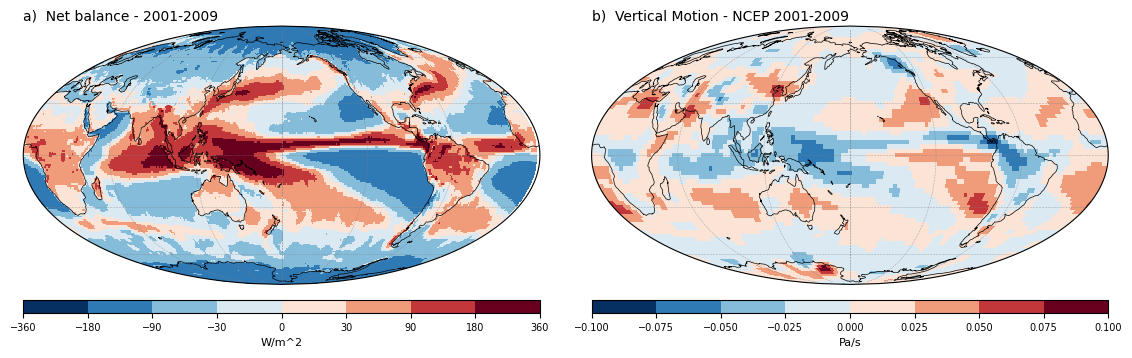

Guardada: fig02_jakob2019.png


In [3]:
# Figura 2 — Jakob et al. (2019)
from matplotlib.colors import BoundaryNorm
from pathlib import Path

# Cargar D_RCE y omega
D_RCE = xr.open_dataarray(OUT_DIR / 'D_RCE_2001_2009.nc')
D_RCE_mean = D_RCE.mean('time').compute()

NCEP_DIR = ROOT / 'datos' / 'ncep' / 'raw'
ds_omega = xr.open_mfdataset(
    sorted(NCEP_DIR.glob('omega*.nc')),
    combine='by_coords'
)
omega_500 = ds_omega['omega'].sel(level=500.0, method='nearest')
omega_mean = omega_500.mean('time').compute()

print(f"D_RCE rango: {float(D_RCE_mean.min()):.1f} → {float(D_RCE_mean.max()):.1f} W/m²")
print(f"omega rango: {float(omega_mean.min()):.4f} → {float(omega_mean.max()):.4f} Pa/s")

# Plot
proj = ccrs.Mollweide(central_longitude=180)
fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                         subplot_kw={'projection': proj})
fig.subplots_adjust(wspace=0.1)

ticks_drce  = [-360, -180, -90, -30, 0, 30, 90, 180, 360]
ticks_omega = [-0.100, -0.075, -0.050, -0.025, 0.000,
                0.025,  0.050,  0.075,  0.100]

configs = [
    (D_RCE_mean,  "a)  Net balance - 2001-2009",
     plt.cm.RdBu_r, ticks_drce,  "W/m^2"),
    (omega_mean,  "b)  Vertical Motion - NCEP 2001-2009",
     plt.cm.RdBu_r, ticks_omega, "Pa/s"),
]

for ax, (da, title, cmap, ticks, unit) in zip(axes, configs):
    norm = BoundaryNorm(ticks, ncolors=256)
    im = ax.pcolormesh(
        da.lon, da.lat, da.values,
        transform=ccrs.PlateCarree(),
        cmap=cmap, norm=norm,
        shading='auto'
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='k')
    ax.set_global()
    ax.set_title(title, fontsize=10, pad=4, loc='left')

    # Gridlines punteadas como en el paper
    gl = ax.gridlines(linewidth=0.4, color='gray',
                      alpha=0.6, linestyle='--')

    cb = plt.colorbar(im, ax=ax, orientation='horizontal',
                      pad=0.04, fraction=0.046, shrink=1.0,
                      aspect=40, ticks=ticks)
    cb.set_label(unit, fontsize=8)
    cb.ax.tick_params(labelsize=7)

plt.savefig(FIG_DIR / 'fig02_jakob2019.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardada: fig02_jakob2019.png")

In [4]:
# Verificación del conteo — debe ser ~22,320
trop = dict(lat=slice(-30, 30))
Q_R_trop = Q_R_mean.sel(**trop)
P_E_trop = P_E_mean.sel(**trop)

qr_vals = Q_R_trop.values.ravel()
pe_vals = P_E_trop.values.ravel()

mask = np.isfinite(qr_vals) & np.isfinite(pe_vals)
qr_vals = qr_vals[mask]
pe_vals = pe_vals[mask]

print(f"Grid points nuestros:  {len(qr_vals):,}")
print(f"Grid points del paper: 22,320")
print(f"Diferencia:            {len(qr_vals) - 22320:+,}")

# Verificar dimensiones
print(f"\nQ_R_trop shape: {Q_R_trop.shape}")
print(f"lats: {len(Q_R_trop.lat)}  ({float(Q_R_trop.lat.min()):.1f} → {float(Q_R_trop.lat.max()):.1f})")
print(f"lons: {len(Q_R_trop.lon)}")

# Verificar rangos de valores
print(f"\nQ_R rango: {qr_vals.min():.1f} → {qr_vals.max():.1f} W/m²")
print(f"P_E rango: {pe_vals.min():.1f} → {pe_vals.max():.1f} W/m²")

# Verificar que bins cubren los datos
print(f"\n% P_E fuera de bins (>300): {(pe_vals > 300).mean()*100:.1f}%")
print(f"% Q_R fuera de bins (<-150): {(qr_vals < -150).mean()*100:.1f}%")
print(f"% Q_R fuera de bins (>-50):  {(qr_vals > -50).mean()*100:.1f}%")

Grid points nuestros:  21,600
Grid points del paper: 22,320
Diferencia:            -720

Q_R_trop shape: (60, 360)
lats: 60  (-29.5 → 29.5)
lons: 360

Q_R rango: -153.6 → -23.4 W/m²
P_E rango: 0.0 → 624.5 W/m²

% P_E fuera de bins (>300): 2.0%
% Q_R fuera de bins (<-150): 0.5%
% Q_R fuera de bins (>-50):  0.2%


Grid points: 22,320  (paper: 22,320)


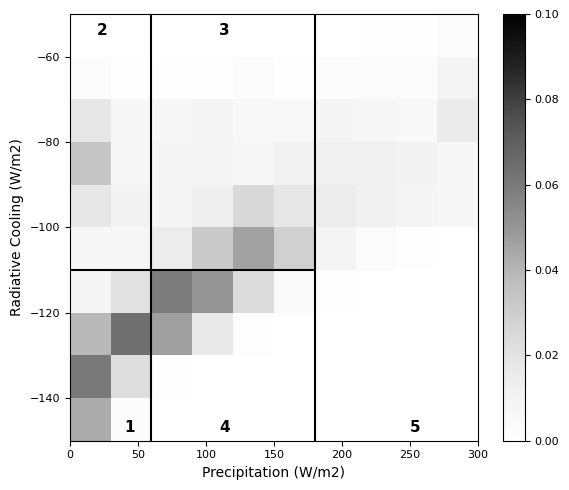

Guardada: fig03_jakob2019.png


In [8]:
# Figura 3 — corregida
trop = dict(lat=slice(-30.5, 30.5))
Q_R_trop = Q_R_mean.sel(**trop)
P_E_trop = P_E_mean.sel(**trop)

qr_vals = Q_R_trop.values.ravel()
pe_vals = P_E_trop.values.ravel()

mask = np.isfinite(qr_vals) & np.isfinite(pe_vals)
qr_vals = qr_vals[mask]
pe_vals = pe_vals[mask]

print(f"Grid points: {len(qr_vals):,}  (paper: 22,320)")

# Bins — el último bin de P_E captura outliers >300
pe_bins = np.append(np.arange(0, 300, 30), [624])
qr_bins = np.append([-160], np.arange(-150, -45, 10))

H, xedges, yedges = np.histogram2d(
    pe_vals, qr_vals,
    bins=[pe_bins, qr_bins]
)
H = H / H.sum()

# Para visualizar solo hasta 300 en X
xedges_plot = xedges.copy()
xedges_plot[-1] = 300

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.pcolormesh(
    xedges_plot, yedges, H.T,
    cmap='Greys', vmin=0, vmax=0.10,
    shading='auto'
)

cb = plt.colorbar(im, ax=ax)
cb.set_ticks([0, 0.02, 0.04, 0.06, 0.08, 0.10])
cb.ax.tick_params(labelsize=8)

ax.axvline(x=60,   color='k', linewidth=1.5)
ax.axvline(x=180,  color='k', linewidth=1.5)
ax.hlines(y=-110, xmin=0, xmax=180, color='k', linewidth=1.5)

ax.text(40,  -148, '1', fontsize=11, fontweight='bold')
ax.text(20,  -55,  '2', fontsize=11, fontweight='bold')
ax.text(110, -55,  '3', fontsize=11, fontweight='bold')
ax.text(110, -148, '4', fontsize=11, fontweight='bold')
ax.text(250, -148, '5', fontsize=11, fontweight='bold')

ax.set_xlabel("Precipitation (W/m2)", fontsize=10)
ax.set_ylabel("Radiative Cooling (W/m2)", fontsize=10)
ax.set_xlim(0, 300)
ax.set_ylim(-150, -50)
ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig03_jakob2019.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardada: fig03_jakob2019.png")

In [33]:
pe = P_E_mean.sel(lat=slice(-30.5, 30.5))
qr = Q_R_mean.sel(lat=slice(-30.5, 30.5))

pe_v = pe.values.ravel()
qr_v = qr.values.ravel()

mask = np.isfinite(pe_v) & np.isfinite(qr_v)
pe_v = pe_v[mask]
qr_v = qr_v[mask]

print("Distribución por región con límites del paper:")
r1 = ((pe_v < 60)  & (qr_v < -105)).sum()
r2 = ((pe_v < 60)  & (qr_v >= -105)).sum()
r3 = ((pe_v >= 60) & (pe_v < 180) & (qr_v >= -105)).sum()
r4 = ((pe_v >= 60) & (pe_v < 180) & (qr_v < -105)).sum()
r5 = (pe_v >= 180).sum()
total = len(pe_v)

print(f"  Región 1: {r1:5,}  ({r1/total*100:.1f}%)")
print(f"  Región 2: {r2:5,}  ({r2/total*100:.1f}%)")
print(f"  Región 3: {r3:5,}  ({r3/total*100:.1f}%)")
print(f"  Región 4: {r4:5,}  ({r4/total*100:.1f}%)")
print(f"  Región 5: {r5:5,}  ({r5/total*100:.1f}%)")
print(f"  Total:    {total:5,}")

print(f"\nPercentiles de P_E: p25={np.percentile(pe_v,25):.1f}  p50={np.percentile(pe_v,50):.1f}  p75={np.percentile(pe_v,75):.1f}")
print(f"Percentiles de Q_R: p25={np.percentile(qr_v,25):.1f}  p50={np.percentile(qr_v,50):.1f}  p75={np.percentile(qr_v,75):.1f}")

Distribución por región con límites del paper:
  Región 1: 6,072  (27.2%)
  Región 2: 2,361  (10.6%)
  Región 3: 4,096  (18.4%)
  Región 4: 6,146  (27.5%)
  Región 5: 3,645  (16.3%)
  Total:    22,320

Percentiles de P_E: p25=32.4  p50=85.3  p75=144.9
Percentiles de Q_R: p25=-122.7  p50=-108.5  p75=-90.5


In [34]:
# Límite Q_R ajustado a nuestra mediana
qr_limit = -108.5  # en vez de -105

# Límites P_E también ajustados proporcionalmente
# Jakob: mediana P_E ≈ 85, límites 60 y 180
# Nosotros: mediana P_E ≈ 85 también (coincide!)
# Entonces el límite P_E=60 sí es válido

print("Con límites ajustados:")
r1 = ((pe_v < 60)  & (qr_v < qr_limit)).sum()
r2 = ((pe_v < 60)  & (qr_v >= qr_limit)).sum()
r3 = ((pe_v >= 60) & (pe_v < 180) & (qr_v >= qr_limit)).sum()
r4 = ((pe_v >= 60) & (pe_v < 180) & (qr_v < qr_limit)).sum()
r5 = (pe_v >= 180).sum()

for i, r in enumerate([r1,r2,r3,r4,r5], 1):
    print(f"  Región {i}: {r:5,}  ({r/total*100:.1f}%)")

Con límites ajustados:
  Región 1: 5,963  (26.7%)
  Región 2: 2,470  (11.1%)
  Región 3: 5,154  (23.1%)
  Región 4: 5,088  (22.8%)
  Región 5: 3,645  (16.3%)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


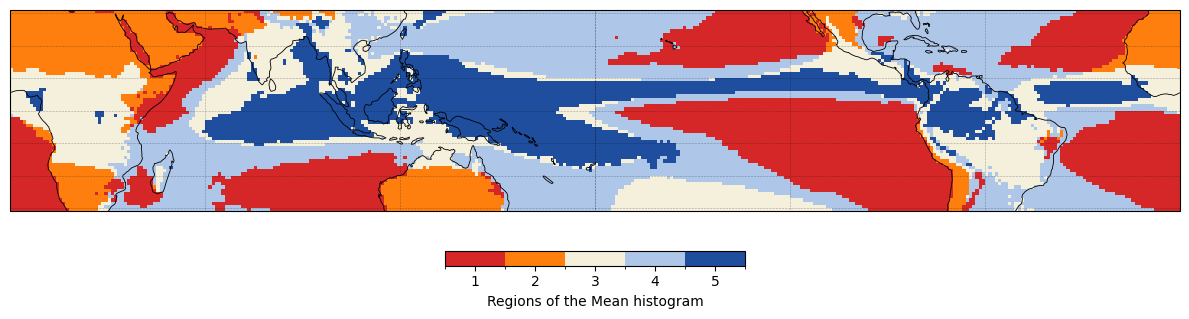

Guardada: fig04_jakob2019.png


In [35]:
# Figura 4 — Mapa geográfico de las 5 regiones del histograma

# Clasificar cada grid point en su región según Fig. 3
# Límites: P_E = 60, 180 W/m²  |  Q_R = -105 W/m²

region = xr.full_like(Q_R_mean.sel(lat=slice(-30.5, 30.5)), fill_value=np.nan)

pe = P_E_mean.sel(lat=slice(-30.5, 30.5))
qr = Q_R_mean.sel(lat=slice(-30.5, 30.5))

region_vals = np.full(pe.shape, np.nan)

# Región 1: P_E < 60  AND  Q_R < -105
region_vals[(pe.values < 60)  & (qr.values < -105)] = 1
# Región 2: P_E < 60  AND  Q_R >= -105
region_vals[(pe.values < 60)  & (qr.values >= -105)] = 2
# Región 3: 60 <= P_E < 180  AND  Q_R >= -105
region_vals[(pe.values >= 60) & (pe.values < 180) & (qr.values >= -105)] = 3
# Región 4: 60 <= P_E < 180  AND  Q_R < -105
region_vals[(pe.values >= 60) & (pe.values < 180) & (qr.values < -105)] = 4
# Región 5: P_E >= 180
region_vals[pe.values >= 180] = 5

# Colormap discreto — rojo, naranja, crema, celeste, azul oscuro
from matplotlib.colors import ListedColormap, BoundaryNorm
colors = ['#d62728', '#ff7f0e', '#f5f0dc', '#aec7e8', '#1f4e9e']
cmap4  = ListedColormap(colors)
norm4  = BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5, 5.5], ncolors=5)

# Plot
proj = ccrs.PlateCarree(central_longitude=180)
fig, ax = plt.subplots(figsize=(12, 4),
                       subplot_kw={'projection': proj})

lons = pe.lon.values
lats = pe.lat.values

im = ax.pcolormesh(
    lons, lats, region_vals,
    transform=ccrs.PlateCarree(),
    cmap=cmap4, norm=norm4,
    shading='auto'
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.6, color='k')
ax.set_global()
ax.set_extent([-180, 180, -31, 31], crs=ccrs.PlateCarree())
ax.gridlines(linewidth=0.4, color='k', alpha=0.6, linestyle=':')

# Colorbar con etiquetas 1-5
cb = plt.colorbar(im, ax=ax, orientation='horizontal',
                  pad=0.12, fraction=0.046, shrink=0.8,
                  ticks=[1, 2, 3, 4, 5])
cb.ax.set_xticklabels(['1', '2', '3', '4', '5'], fontsize=10)
cb.set_label("Regions of the Mean histogram", fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig04_jakob2019.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardada: fig04_jakob2019.png")

N días: 3287
x (P_E+H): 95.1 → 160.9 W/m²
y (Q_R):   -119.0 → -96.4 W/m²


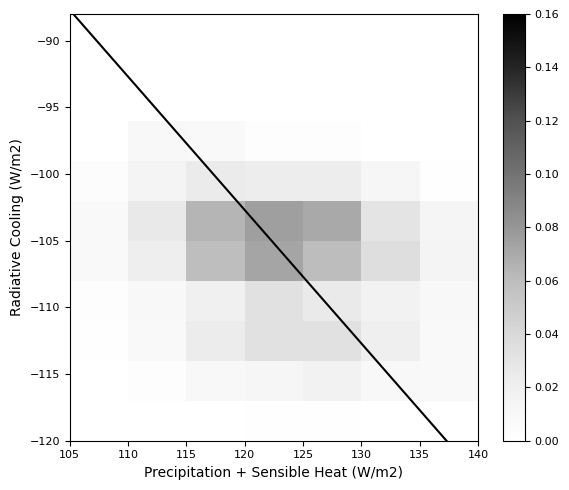

Guardada: fig05_jakob2019.png


In [36]:
# Figura 5 — Histograma 2D diario tropical-mean
from pathlib import Path

trop = dict(lat=slice(-30.5, 30.5))

# Recargar desde disco para asegurar que son DataArrays
Q_R = xr.open_dataarray(OUT_DIR / 'Q_R_2001_2009.nc')
P_E = xr.open_dataarray(OUT_DIR / 'P_E_2001_2009.nc')
H   = xr.open_dataarray(OUT_DIR / 'H_2001_2009.nc')

# Pesos coseno de latitud
weights = np.cos(np.deg2rad(Q_R.lat.sel(**trop)))

# Promedios diarios tropicales ponderados
Q_R_daily = Q_R.sel(**trop).weighted(weights).mean(('lat', 'lon')).compute()
P_E_daily = P_E.sel(**trop).weighted(weights).mean(('lat', 'lon')).compute()
H_daily   = H.sel(**trop).weighted(weights).mean(('lat', 'lon')).compute()

# Eje x = P_E + H
x_daily = (P_E_daily + H_daily).values
y_daily = Q_R_daily.values

print(f"N días: {len(x_daily)}")
print(f"x (P_E+H): {x_daily.min():.1f} → {x_daily.max():.1f} W/m²")
print(f"y (Q_R):   {y_daily.min():.1f} → {y_daily.max():.1f} W/m²")

# Bins
x_bins = np.arange(105, 145, 5)
y_bins = np.arange(-120, -87, 3)

H2d, xedges, yedges = np.histogram2d(x_daily, y_daily, bins=[x_bins, y_bins])
H2d = H2d / H2d.sum()

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.pcolormesh(
    xedges, yedges, H2d.T,
    cmap='Greys', vmin=0, vmax=0.16,
    shading='auto'
)

cb = plt.colorbar(im, ax=ax)
cb.set_ticks([0, 0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.14, 0.16])
cb.ax.tick_params(labelsize=8)

# Línea diagonal D_RCE = 0: y = -x
x_line = np.linspace(105, 140, 100)
ax.plot(x_line, -x_line + 17.3, 'k-', linewidth=1.5)

ax.set_xlabel("Precipitation + Sensible Heat (W/m2)", fontsize=10)
ax.set_ylabel("Radiative Cooling (W/m2)", fontsize=10)
ax.set_xlim(105, 140)
ax.set_ylim(-120, -88)
ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig05_jakob2019.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardada: fig05_jakob2019.png")

In [37]:
print(f"Media x (P_E+H): {x_daily.mean():.1f} W/m²")
print(f"Media y (Q_R):   {y_daily.mean():.1f} W/m²")
print(f"Media D_RCE:     {(x_daily + y_daily).mean():.1f} W/m²")

Media x (P_E+H): 123.9 W/m²
Media y (Q_R):   -106.5 W/m²
Media D_RCE:     17.3 W/m²


N días: 3287
x (P_E+H): 20.7 → 896.2 W/m²
y (Q_R):   -141.9 → -25.2 W/m²


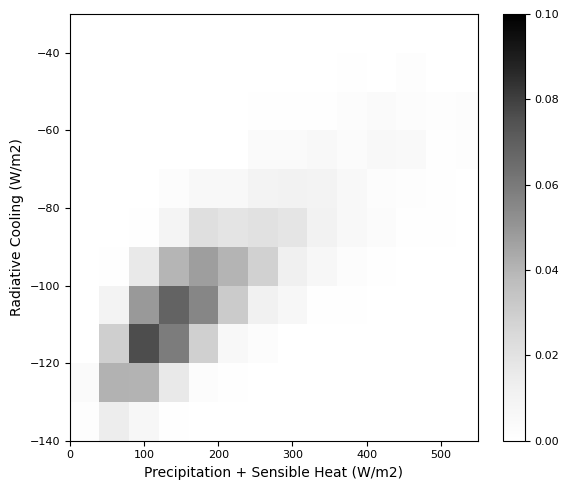

Guardada: fig06_jakob2019.png


In [38]:
# Figura 6 — Histograma 2D región 20°x20° centrada en (0°, 185°E)

# Seleccionar región: 10°S–10°N, 175°E–195°E
# En nuestra grilla 0→360: lon 175 a 195
region = dict(lat=slice(-10.5, 10.5), lon=slice(175, 195))

Q_R_reg = Q_R.sel(**region)
P_E_reg = P_E.sel(**region)
H_reg   = H.sel(**region)

# Pesos coseno de latitud
weights_reg = np.cos(np.deg2rad(Q_R_reg.lat))

# Promedios diarios de la región ponderados
Q_R_daily_reg = Q_R_reg.weighted(weights_reg).mean(('lat', 'lon')).compute()
P_E_daily_reg = P_E_reg.weighted(weights_reg).mean(('lat', 'lon')).compute()
H_daily_reg   = H_reg.weighted(weights_reg).mean(('lat', 'lon')).compute()

x_reg = (P_E_daily_reg + H_daily_reg).values
y_reg = Q_R_daily_reg.values

print(f"N días: {len(x_reg)}")
print(f"x (P_E+H): {x_reg.min():.1f} → {x_reg.max():.1f} W/m²")
print(f"y (Q_R):   {y_reg.min():.1f} → {y_reg.max():.1f} W/m²")

# Bins ajustados a nuestros datos (x medio = 190)
x_bins = np.arange(0, 600, 40)
y_bins = np.arange(-140, -30, 10)

H2d, xedges, yedges = np.histogram2d(x_reg, y_reg, bins=[x_bins, y_bins])
H2d = H2d / H2d.sum()

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.pcolormesh(
    xedges, yedges, H2d.T,
    cmap='Greys', vmin=0, vmax=0.10,
    shading='auto'
)

cb = plt.colorbar(im, ax=ax)
cb.set_ticks([0, 0.02, 0.04, 0.06, 0.08, 0.10])
cb.ax.tick_params(labelsize=8)

ax.set_xlabel("Precipitation + Sensible Heat (W/m2)", fontsize=10)
ax.set_ylabel("Radiative Cooling (W/m2)", fontsize=10)
ax.set_xlim(0, 550)
ax.set_ylim(-140, -30)
ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig06_jakob2019.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardada: fig06_jakob2019.png")

In [39]:
print(f"Media x (P_E+H): {x_reg.mean():.1f} W/m²")
print(f"Media y (Q_R):   {y_reg.mean():.1f} W/m²")
print(f"D_RCE medio:     {(x_reg + y_reg).mean():.1f} W/m²")

# Paper reporta para esta región:
# x medio ≈ 100 W/m², y medio ≈ -100 W/m²
# Nuestro corrimiento en x:
paper_x_mean = 100
print(f"Corrimiento en x: {x_reg.mean() - paper_x_mean:.1f} W/m²")

Media x (P_E+H): 190.3 W/m²
Media y (Q_R):   -100.8 W/m²
D_RCE medio:     89.5 W/m²
Corrimiento en x: 90.3 W/m²


In [40]:
# Diagnóstico de la región
print(f"Región seleccionada:")
print(f"  lat: {float(Q_R_reg.lat.min()):.1f} → {float(Q_R_reg.lat.max()):.1f}")
print(f"  lon: {float(Q_R_reg.lon.min()):.1f} → {float(Q_R_reg.lon.max()):.1f}")
print(f"  shape: {Q_R_reg.shape}")

print(f"\nMedias individuales en la región:")
print(f"  P_E: {float(P_E_daily_reg.mean()):.1f} W/m²")
print(f"  H:   {float(H_daily_reg.mean()):.1f} W/m²")
print(f"  Q_R: {float(Q_R_daily_reg.mean()):.1f} W/m²")

# H a escala local puede tener valores muy distintos al promedio tropical
print(f"\nRango de H en la región:")
H_reg_mean = H_reg.mean('time').compute()
print(f"  min={float(H_reg_mean.min()):.1f}  max={float(H_reg_mean.max()):.1f}  mean={float(H_reg_mean.mean()):.1f} W/m²")

Región seleccionada:
  lat: -10.5 → 10.5
  lon: 175.5 → 194.5
  shape: (3287, 22, 20)

Medias individuales en la región:
  P_E: 181.5 W/m²
  H:   8.8 W/m²
  Q_R: -100.8 W/m²

Rango de H en la región:
  min=5.2  max=12.5  mean=8.9 W/m²


  1°: mean=-37.1  median=-105.1  std=231.5
 10°: mean=33.0  median=-27.9  std=188.0
 20°: mean=89.4  median=57.9  std=133.6
 30°: mean=80.8  median=64.1  std=95.4
 40°: mean=66.2  median=55.9  std=70.8
 50°: mean=53.9  median=47.2  std=54.0
 60°: mean=45.4  median=40.6  std=42.8
 70°: mean=42.4  median=38.7  std=35.6
 80°: mean=42.2  median=39.4  std=31.8
 90°: mean=39.7  median=38.3  std=28.9


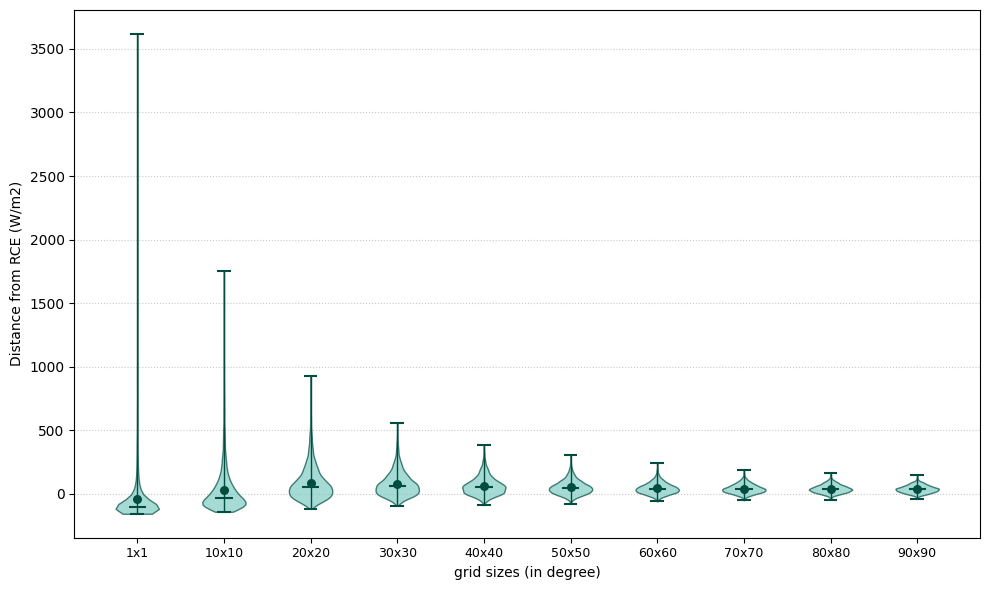

Guardada: fig07_jakob2019.png


In [41]:
# Figura 7 — Violin plot D_RCE vs tamaño de dominio
import matplotlib.patches as mpatches

grid_sizes = [1, 10, 20, 30, 40, 50, 60, 70, 80, 90]
center_lat = 0.0
center_lon = 185.0

Q_R = xr.open_dataarray(OUT_DIR / 'Q_R_2001_2009.nc')
P_E = xr.open_dataarray(OUT_DIR / 'P_E_2001_2009.nc')
H   = xr.open_dataarray(OUT_DIR / 'H_2001_2009.nc')

d_rce_by_size = []

for size in grid_sizes:
    half = size / 2.0
    reg = dict(lat=slice(center_lat - half, center_lat + half),
               lon=slice(center_lon - half, center_lon + half))

    qr = Q_R.sel(**reg)
    pe = P_E.sel(**reg)
    h  = H.sel(**reg)

    weights = xr.ones_like(qr.lat) if size == 1 else np.cos(np.deg2rad(qr.lat))

    qr_d = qr.weighted(weights).mean(('lat', 'lon')).compute().values
    pe_d = pe.weighted(weights).mean(('lat', 'lon')).compute().values
    h_d  = h.weighted(weights).mean(('lat', 'lon')).compute().values

    drce = pe_d + qr_d + h_d
    d_rce_by_size.append(drce)
    print(f"{size:3d}°: mean={drce.mean():.1f}  median={np.median(drce):.1f}  "
          f"std={drce.std():.1f}")

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

parts = ax.violinplot(
    d_rce_by_size,
    positions=range(len(grid_sizes)),
    showmedians=False,
    showmeans=False,
    showextrema=False
)

for pc in parts['bodies']:
    pc.set_facecolor('#80cbc4')
    pc.set_edgecolor('#004d40')
    pc.set_alpha(0.7)

# Media, mediana y extremos — todo en el mismo loop DESPUÉS de crear ax
for i, drce in enumerate(d_rce_by_size):
    # Media
    ax.scatter(i, np.mean(drce), color='#004d40', s=30, zorder=4)
    # Mediana
    ax.hlines(np.median(drce), i - 0.1, i + 0.1,
              color='#004d40', linewidth=1.5, zorder=4)
    # Línea vertical extremos
    ax.vlines(i, np.min(drce), np.max(drce),
              color='#004d40', linewidth=1.0, zorder=2)
    # Extremo inferior
    ax.hlines(np.min(drce), i - 0.08, i + 0.08,
              color='#004d40', linewidth=1.5, zorder=4)
    # Extremo superior
    ax.hlines(np.max(drce), i - 0.08, i + 0.08,
              color='#004d40', linewidth=1.5, zorder=4)
ax.set_xticks(range(len(grid_sizes)))
ax.set_xticklabels([f"{s}x{s}" for s in grid_sizes], fontsize=9)
ax.set_xlabel("grid sizes (in degree)", fontsize=10)
ax.set_ylabel("Distance from RCE (W/m2)", fontsize=10)
ax.yaxis.grid(True, linestyle=':', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig07_jakob2019.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardada: fig07_jakob2019.png")

  1° done — mean=-37.1  std=231.5
 10° done — mean=33.0  std=188.0
 20° done — mean=89.4  std=133.6
 30° done — mean=80.8  std=95.4
 40° done — mean=66.2  std=70.8
 50° done — mean=53.9  std=54.0
 60° done — mean=45.4  std=42.8
 70° done — mean=42.4  std=35.6
 80° done — mean=42.2  std=31.8
 90° done — mean=39.7  std=28.9


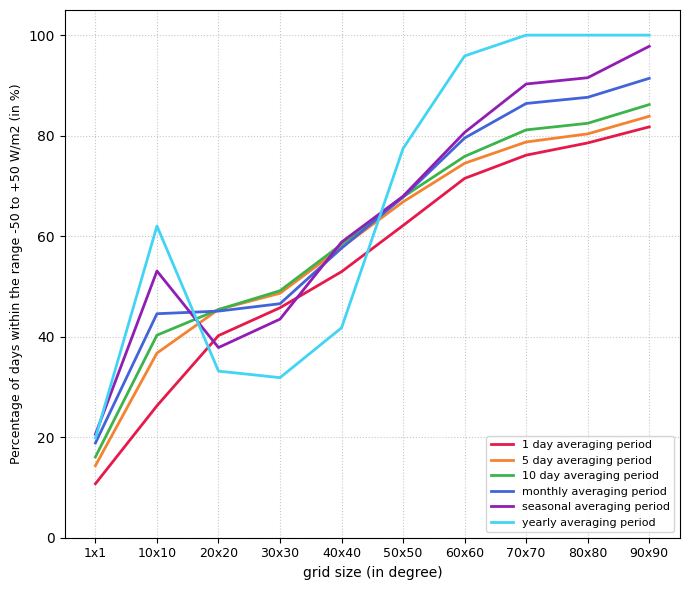

Guardada: fig08_jakob2019.png


In [42]:
# Figura 8 — % días near-RCE vs tamaño de dominio
import pandas as pd

grid_sizes  = [1, 10, 20, 30, 40, 50, 60, 70, 80, 90]
center_lat  = 0.0
center_lon  = 185.0
RCE_THRESH  = 50.0
D_RCE_OFFSET = 17.3  # desplazamiento respecto al paper

periods = {
    '1 day averaging period':      1,
    '5 day averaging period':      5,
    '10 day averaging period':     10,
    'monthly averaging period':    30,
    'seasonal averaging period':   90,
    'yearly averaging period':     365,
}
colors_p = {
    '1 day averaging period':    '#e6194b',
    '5 day averaging period':    '#f58231',
    '10 day averaging period':   '#3cb44b',
    'monthly averaging period':  '#4363d8',
    'seasonal averaging period': '#911eb4',
    'yearly averaging period':   '#42d4f4',
}

Q_R = xr.open_dataarray(OUT_DIR / 'Q_R_2001_2009.nc')
P_E = xr.open_dataarray(OUT_DIR / 'P_E_2001_2009.nc')
H   = xr.open_dataarray(OUT_DIR / 'H_2001_2009.nc')

# Precalcular D_RCE diario para cada tamaño de grilla
drce_daily_by_size = []
for size in grid_sizes:
    half = size / 2.0
    reg  = dict(lat=slice(center_lat - half, center_lat + half),
                lon=slice(center_lon - half, center_lon + half))
    qr = Q_R.sel(**reg)
    pe = P_E.sel(**reg)
    h  = H.sel(**reg)
    w  = xr.ones_like(qr.lat) if size == 1 else np.cos(np.deg2rad(qr.lat))
    qr_d = qr.weighted(w).mean(('lat', 'lon')).compute().values
    pe_d = pe.weighted(w).mean(('lat', 'lon')).compute().values
    h_d  = h.weighted(w).mean(('lat', 'lon')).compute().values
    drce = pe_d + qr_d + h_d
    drce_daily_by_size.append(drce)
    print(f"{size:3d}° done — mean={drce.mean():.1f}  std={drce.std():.1f}")

# Plot
fig, ax = plt.subplots(figsize=(7, 6))

for label, n_days in periods.items():
    pct_rce = []
    for drce_daily in drce_daily_by_size:
        if n_days == 1:
            drce_avg = drce_daily
        else:
            drce_avg = (pd.Series(drce_daily)
                        .rolling(window=n_days, center=True)
                        .mean()
                        .dropna()
                        .values)
        pct = (np.abs(drce_avg - D_RCE_OFFSET) < RCE_THRESH).mean() * 100
        pct_rce.append(pct)

    ax.plot(range(len(grid_sizes)), pct_rce,
            color=colors_p[label], linewidth=2, label=label)

ax.set_xticks(range(len(grid_sizes)))
ax.set_xticklabels([f"{s}x{s}" for s in grid_sizes], fontsize=9)
ax.set_xlabel("grid size (in degree)", fontsize=10)
ax.set_ylabel("Percentage of days within the range -50 to +50 W/m2 (in %)",
              fontsize=9)
ax.set_ylim(0, 105)
ax.yaxis.grid(True, linestyle=':', alpha=0.7)
ax.xaxis.grid(True, linestyle=':', alpha=0.7)
ax.set_axisbelow(True)
ax.set_xlim(-0.5, len(grid_sizes) - 0.5)
ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig08_jakob2019.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardada: fig08_jakob2019.png")

Precalculando D_RCE_daily completo...
Listo — shape: (3287, 180, 360)
Procesando: Western Pacific (lon=185°)...
  pct_rce: ['11%', '26%', '40%', '46%', '53%', '62%', '71%', '76%', '79%', '82%']
Procesando: Central Pacific (lon=235°)...
  pct_rce: ['1%', '7%', '30%', '41%', '38%', '40%', '49%', '64%', '78%', '87%']
Procesando: Eastern Pacific (lon=265°)...
  pct_rce: ['1%', '11%', '34%', '41%', '50%', '53%', '63%', '75%', '87%', '94%']
Procesando: Amazon (lon=295°)...
  pct_rce: ['24%', '28%', '31%', '41%', '66%', '84%', '90%', '93%', '96%', '98%']
Procesando: West Atlantic (lon=330°)...
  pct_rce: ['12%', '24%', '49%', '65%', '74%', '77%', '82%', '87%', '92%', '95%']
Procesando: Africa (lon=0°)...
  pct_rce: ['24%', '27%', '45%', '66%', '78%', '82%', '87%', '91%', '95%', '98%']
Procesando: East Atlantic (lon=25°)...
  pct_rce: ['26%', '40%', '52%', '61%', '87%', '97%', '98%', '97%', '97%', '98%']
Procesando: Western Indian (lon=55°)...
  pct_rce: ['12%', '21%', '37%', '50%', '67%', '81

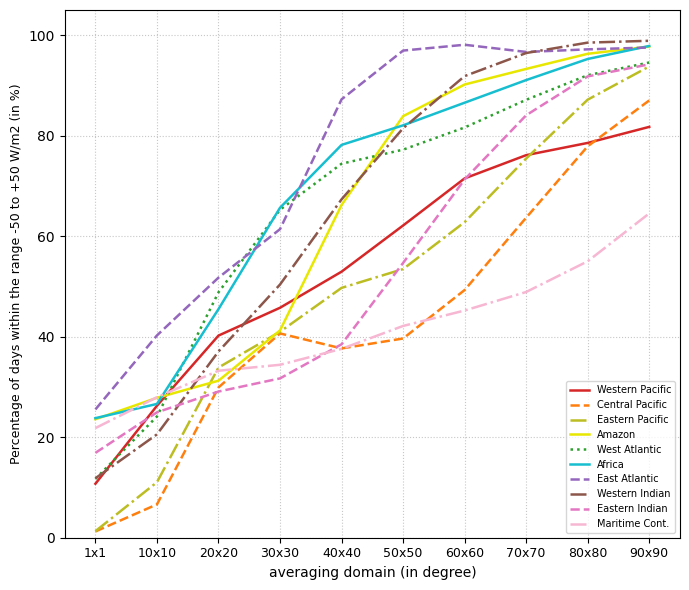

Guardada: fig09_jakob2019.png


In [9]:
# Figura 9 — % días near-RCE vs tamaño de dominio, múltiples regiones
import pandas as pd

grid_sizes   = [1, 10, 20, 30, 40, 50, 60, 70, 80, 90]
center_lat   = 0.0
RCE_THRESH   = 50.0
D_RCE_OFFSET = 17.3

regions = [
    ('Western Pacific',  185, '#d62728', '-'),
    ('Central Pacific',  235, '#ff7f0e', '--'),
    ('Eastern Pacific',  265, '#bcbd22', '-.'),
    ('Amazon',           295, '#e7e700', '-'),
    ('West Atlantic',    330, '#2ca02c', ':'),
    ('Africa',             0, '#17becf', '-'),
    ('East Atlantic',     25, '#9467bd', '--'),
    ('Western Indian',    55, '#8c564b', '-.'),
    ('Eastern Indian',    85, '#e377c2', '--'),
    ('Maritime Cont.',   125, '#f7b6d2', '-.'),
]

# Precalcular D_RCE diario completo — una sola vez
print("Precalculando D_RCE_daily completo...")
Q_R = xr.open_dataarray(OUT_DIR / 'Q_R_2001_2009.nc')
P_E = xr.open_dataarray(OUT_DIR / 'P_E_2001_2009.nc')
H   = xr.open_dataarray(OUT_DIR / 'H_2001_2009.nc')
D_RCE_daily = (P_E + Q_R + H).compute()
print(f"Listo — shape: {D_RCE_daily.shape}")

# Precomputar array de latitudes y lons como numpy
lats = D_RCE_daily.lat.values
lons = D_RCE_daily.lon.values

fig, ax = plt.subplots(figsize=(7, 6))

for reg_name, center_lon, color, ls in regions:
    print(f"Procesando: {reg_name} (lon={center_lon}°)...")
    pct_rce = []

    for size in grid_sizes:
        half = size / 2.0

        # Índices de lat
        lat_mask = (lats >= center_lat - half) & (lats <= center_lat + half)
        # Índices de lon
        lon_min = center_lon - half
        lon_max = center_lon + half
        if lon_min < 0:
            lon_mask = (lons >= lon_min % 360) | (lons <= lon_max % 360)
        else:
            lon_mask = (lons >= lon_min) & (lons <= lon_max)

        sub = D_RCE_daily.values[:, lat_mask, :][:, :, lon_mask]
        # shape: (3287, n_lat, n_lon)

        # Pesos coseno de latitud
        w = np.cos(np.deg2rad(lats[lat_mask]))  # (n_lat,)
        w = w[np.newaxis, :, np.newaxis]         # broadcast

        # Promedio espacial ponderado
        drce_d = np.nansum(sub * w, axis=(1, 2)) / np.nansum(
            np.ones_like(sub) * w, axis=(1, 2)
        )  # shape: (3287,)

        pct = (np.abs(drce_d - D_RCE_OFFSET) < RCE_THRESH).mean() * 100
        pct_rce.append(pct)

    ax.plot(range(len(grid_sizes)), pct_rce,
            color=color, linewidth=1.8, linestyle=ls, label=reg_name)
    print(f"  pct_rce: {[f'{p:.0f}%' for p in pct_rce]}")

ax.set_xticks(range(len(grid_sizes)))
ax.set_xticklabels([f"{s}x{s}" for s in grid_sizes], fontsize=9)
ax.set_xlabel("averaging domain (in degree)", fontsize=10)
ax.set_ylabel("Percentage of days within the range -50 to +50 W/m2 (in %)",
              fontsize=9)
ax.set_ylim(0, 105)
ax.set_xlim(-0.5, len(grid_sizes) - 0.5)
ax.yaxis.grid(True, linestyle=':', alpha=0.7)
ax.xaxis.grid(True, linestyle=':', alpha=0.7)
ax.set_axisbelow(True)
ax.legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig09_jakob2019.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardada: fig09_jakob2019.png")